In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
np.random.seed(42)

# Number of rows
n = 500

# Dataset
data = {
    "Customer_ID": np.random.randint(1000, 1100, n),
    "Customer_Name": np.random.choice(["Amit","Priya","Rahul","Sneha","Karan","Neha","Arjun","Meera","Rohan","Pooja"], n),
    "Region": np.random.choice(["North","South","East","West"], n),
    "Order_ID": np.arange(5000, 5000+n),
    "Product": np.random.choice(["Laptop","Mobile","Shoes","Watch","Tablet","T-shirt","Headphones","Bag","Camera","Sandals"], n),
    "Category": np.random.choice(["Electronics","Fashion","Accessories"], n),
    "Amount": np.random.randint(500, 60000, n),
    "Order_Date": pd.date_range(start="2024-01-01", periods=n, freq="D")
}

df = pd.DataFrame(data)

print(df.head())
print(df.shape)

   Customer_ID Customer_Name Region  Order_ID  Product     Category  Amount  \
0         1051         Pooja  South      5000      Bag  Accessories   31997   
1         1092         Rahul   West      5001  T-shirt  Electronics   39756   
2         1014         Karan   East      5002  T-shirt  Electronics   54389   
3         1071          Neha   East      5003   Tablet      Fashion   56177   
4         1060         Rohan  North      5004      Bag  Accessories   37118   

  Order_Date  
0 2024-01-01  
1 2024-01-02  
2 2024-01-03  
3 2024-01-04  
4 2024-01-05  
(500, 8)


In [3]:
# q1
df["Order_Date"]=pd.to_datetime(df["Order_Date"])
df

,Customer_ID,Customer_Name,Region,Order_ID,Product,Category,Amount,Order_Date
0,1051,Pooja,South,5000,Bag,Accessories,31997,2024-01-01
1,1092,Rahul,West,5001,T-shirt,Electronics,39756,2024-01-02
2,1014,Karan,East,5002,T-shirt,Electronics,54389,2024-01-03
3,1071,Neha,East,5003,Tablet,Fashion,56177,2024-01-04
4,1060,Rohan,North,5004,Bag,Accessories,37118,2024-01-05
...,...,...,...,...,...,...,...,...
495,1062,Karan,East,5495,Watch,Accessories,57114,2025-05-10
496,1068,Priya,South,5496,Mobile,Accessories,5605,2025-05-11
497,1021,Karan,South,5497,Headphones,Electronics,52630,2025-05-12
498,1092,Meera,East,5498,T-shirt,Accessories,29812,2025-05-13


In [4]:
df["Order_month"]=df["Order_Date"].dt.month
df

,Customer_ID,Customer_Name,Region,Order_ID,Product,Category,Amount,Order_Date,Order_month
0,1051,Pooja,South,5000,Bag,Accessories,31997,2024-01-01,1
1,1092,Rahul,West,5001,T-shirt,Electronics,39756,2024-01-02,1
2,1014,Karan,East,5002,T-shirt,Electronics,54389,2024-01-03,1
3,1071,Neha,East,5003,Tablet,Fashion,56177,2024-01-04,1
4,1060,Rohan,North,5004,Bag,Accessories,37118,2024-01-05,1
...,...,...,...,...,...,...,...,...,...
495,1062,Karan,East,5495,Watch,Accessories,57114,2025-05-10,5
496,1068,Priya,South,5496,Mobile,Accessories,5605,2025-05-11,5
497,1021,Karan,South,5497,Headphones,Electronics,52630,2025-05-12,5
498,1092,Meera,East,5498,T-shirt,Accessories,29812,2025-05-13,5


In [5]:
# Q2. Using matplotlib, create a line plot showing total sales (Amount) per month.
monthly_sales=df.groupby("Order_month")["Amount"].sum().reset_index()
monthly_sales

,Order_month,Amount
0,1,1984115
1,2,1639413
2,3,1888887
3,4,1816485
4,5,1552680
5,6,919421
6,7,1007951
7,8,965430
8,9,1117383
9,10,918099


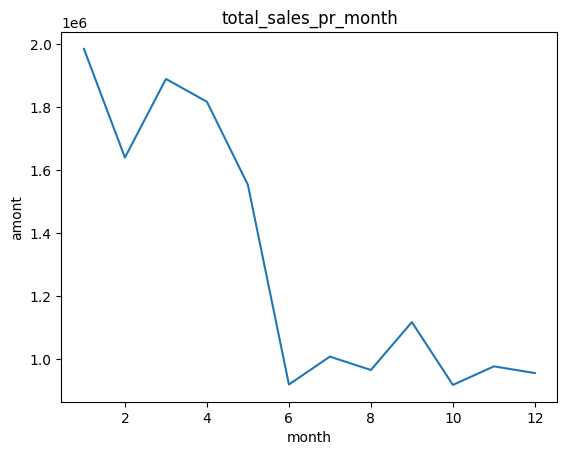

In [6]:
plt.plot(monthly_sales["Order_month"],monthly_sales["Amount"])

plt.title("total_sales_pr_month")
plt.xlabel("month")
plt.ylabel("amont")

plt.show()

In [7]:
# Q3. Create a bar chart (matplotlib) showing total sales for each Product.
product_wise_sales=df.groupby("Product")["Amount"].sum().reset_index()
product_wise_sales

,Product,Amount
0,Bag,1559113
1,Camera,1625623
2,Headphones,1510997
3,Laptop,1801238
4,Mobile,1757774
5,Sandals,1537205
6,Shoes,1642805
7,T-shirt,1827579
8,Tablet,1068484
9,Watch,1411689


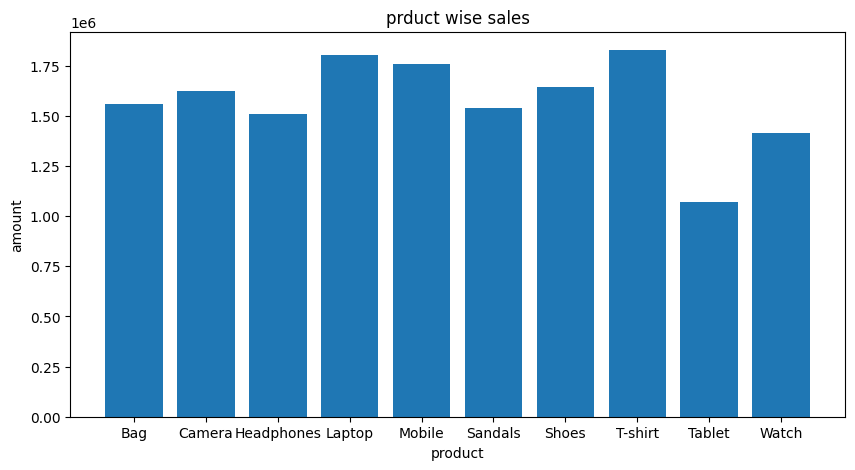

In [8]:
plt.figure(figsize=(10,5))
plt.bar(product_wise_sales["Product"],product_wise_sales["Amount"])

plt.title("prduct wise sales")
plt.xlabel("product")
plt.ylabel("amount")

plt.show()

In [9]:
# Q4. Create a pie chart (matplotlib) to show proportion of sales by Category
category_sales = df.groupby("Category")["Amount"].sum().reset_index()
category_sales

,Category,Amount
0,Accessories,4586772
1,Electronics,5484380
2,Fashion,5671355


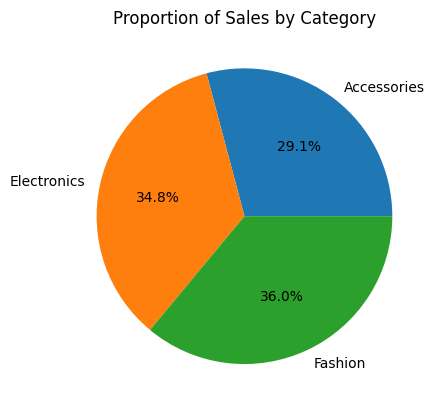

In [10]:
plt.pie(category_sales["Amount"], labels=category_sales["Category"], autopct='%1.1f%%')
plt.title("Proportion of Sales by Category")

plt.show()

In [11]:
# # Q5. Handle missing values in 'Amount' column (fill or drop).
# Then re-plot any one graph and observe the difference.

In [12]:
# Q6. Using seaborn, create a countplot showing number of orders per Region.

In [13]:
# Q7. Create a seaborn barplot showing average Amount spent per Product.
avg_pr_product=df.groupby("Product")["Amount"].mean().reset_index()
avg_pr_product

,Product,Amount
0,Bag,28872.462963
1,Camera,30104.129630
2,Headphones,32847.760870
3,Laptop,36024.760000
4,Mobile,29792.779661
5,Sandals,30744.100000
6,Shoes,31592.403846
7,T-shirt,38074.562500
8,Tablet,24848.465116
9,Watch,32083.840909


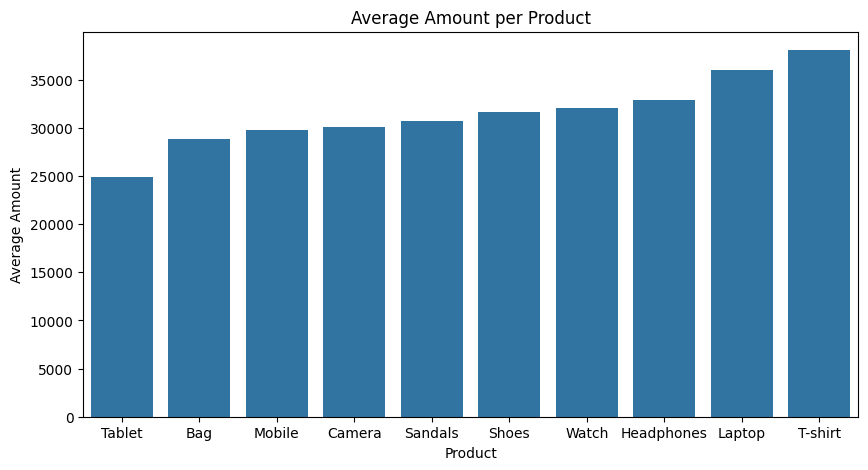

In [14]:
avg_pr_product = avg_pr_product.sort_values(by="Amount")
plt.figure(figsize=(10,5))
sns.barplot(data=avg_pr_product, x="Product", y="Amount")

plt.title("Average Amount per Product")
plt.xlabel("Product")
plt.ylabel("Average Amount")

plt.show()

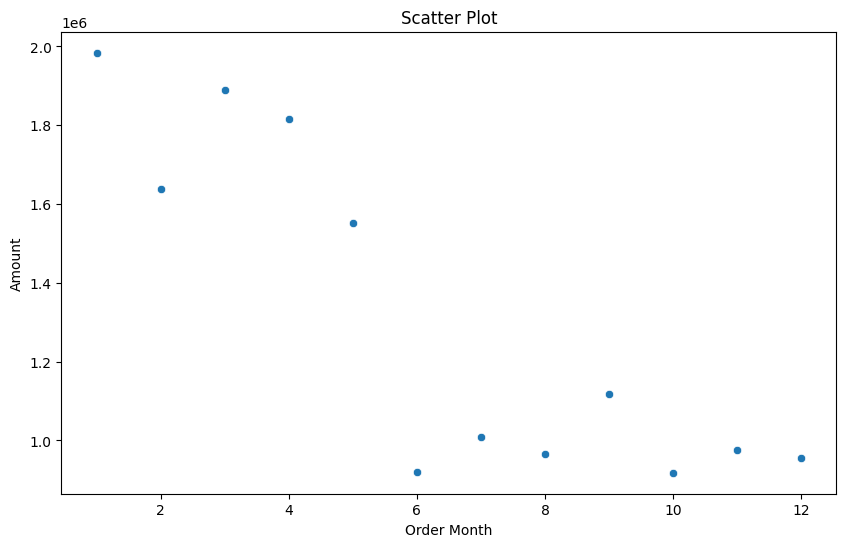

In [15]:
# Q8. Create a scatterplot between Order_Month and Amount.
# Add hue using Product to differentiate points.
plt.figure(figsize=(10,6))

sns.scatterplot(data=monthly_sales, x="Order_month", y="Amount")
plt.title("Scatter Plot")
plt.xlabel("Order Month")
plt.ylabel("Amount")

plt.show()

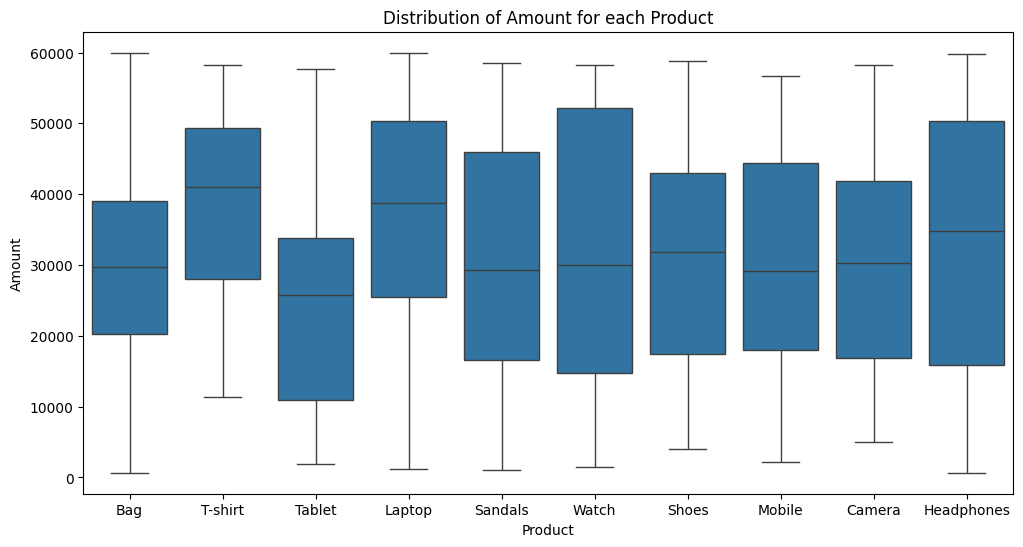

In [16]:
# Q9. Create a boxplot using seaborn to show distribution of Amount for each Product
plt.figure(figsize=(12,6))

sns.boxplot(data=df, x="Product", y="Amount")

plt.title("Distribution of Amount for each Product")
plt.xlabel("Product")
plt.ylabel("Amount")

plt.show()

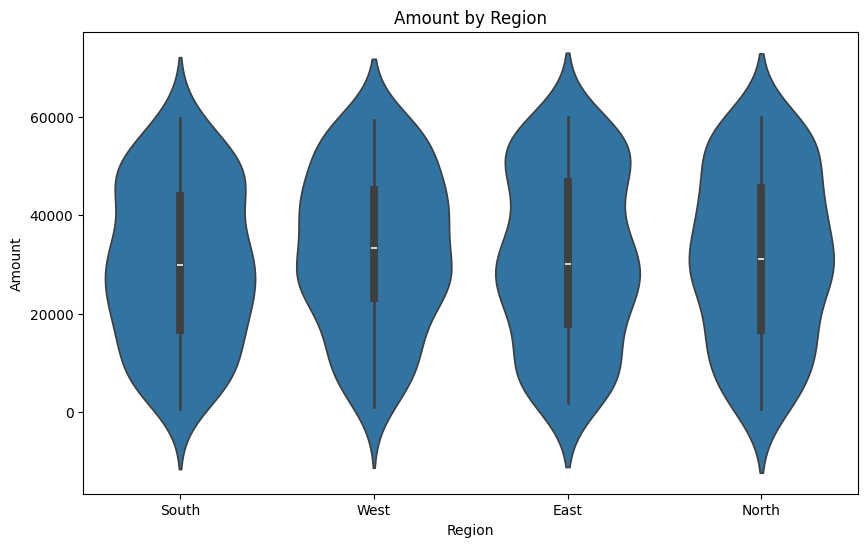

In [ ]:
# Q10. Create a violin plot for Amount grouped by Region.
plt.figure(figsize=(10,6))

sns.violinplot(data=df, x="Region", y="Amount")

plt.title("Amount by Region")
plt.xlabel("Region")
plt.ylabel("Amount")

plt.show()

In [ ]:
# Q11. Convert all values in 'Category' column to lowercase.
# Then create a countplot to show category distribution.


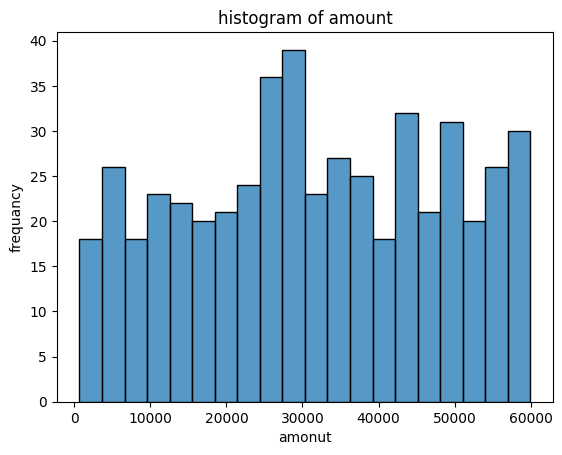

In [23]:
# Q12. Create a histogram (matplotlib or seaborn) for Amount column.
sns.histplot(df["Amount"],bins=20)
plt.title("histogram of amount")
plt.xlabel("amonut")
plt.ylabel("frequancy")

plt.show()

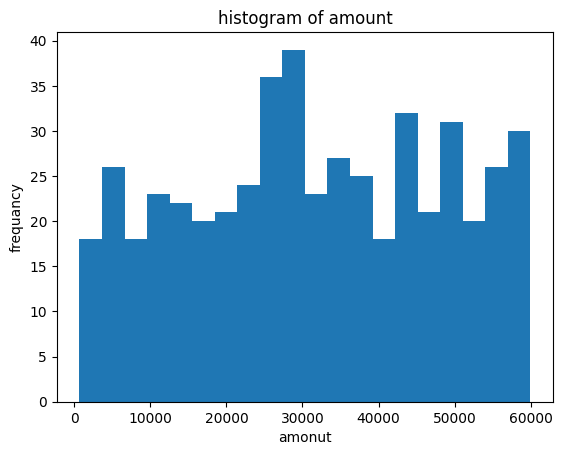

In [25]:
plt.hist(df["Amount"],bins=20)
plt.title("histogram of amount")
plt.xlabel("amonut")
plt.ylabel("frequancy")

plt.show()

In [ ]:
# Q13. Use seaborn's pairplot on numerical columns (if applicable).
# Observe relationships between variables.


In [ ]:
# Q14. Apply different seaborn styles (darkgrid, whitegrid) and compare any one plot.

In [ ]:
# Q15. Create a combined plot:
# - Use matplotlib to plot total monthly sales
# - Add markers, title, labels, and legend

In [ ]:
#16
# Try to find which Region contributes highest sales and visualize it.